# Training your Custom Datasets with YOLOv11

In [ ]:
!nvidia-smi

Fri Jun  6 04:11:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Installing Ultralytics

In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.5/112.6 GB disk)


### Dataset Preparation

[Dataset LINK](https://universe.roboflow.com/roboflow-58fyf/rock-paper-scissors-sxsw)

Download the Dataset in YOLOv11 format from Roboflow Universe

(Optional) Upload the dataset in Google Drive

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="OW0NGyO0XjTOUAZ7RAiE")
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 126.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-14 in yolov11:: 100%|██████████| 14682/14682 [00:01<00:00, 8010.87it/s] 


In [ ]:
%cd /content/rock-paper-scissors-14

/content/rock-paper-scissors-14


# Using the Command Line Interface

In [ ]:
!cat /content/rock-paper-scissors-14/data.yaml

train: /content/rock-paper-scissors-14/train/images
val: /content/rock-paper-scissors-14/valid/images
test: /content/rock-paper-scissors-14/test/images

nc: 3
names: ['Paper', 'Rock', 'Scissors']

### Starting the Training Procedure

In [ ]:
# Train YOLO11n on Rock Paper Scissors Dataset for 25 epochs for better results
!yolo train model=yolo11n.pt data="/content/rock-paper-scissors-14/data.yaml" epochs=10 imgsz=640

100% 5.35M/5.35M [00:00<00:00, 327MB/s]
Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock-paper-scissors-14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

# Validating the Trained Model

In [ ]:
# Validate Trained Model on Validation Set
!yolo val model="/content/runs/detect/train/weights/best.pt" data="/content/rock-paper-scissors-14/data.yaml"

Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1265.7±372.1 MB/s, size: 29.2 KB)
val: Scanning /content/rock-paper-scissors-14/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100% 576/576 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 36/36 [00:05<00:00,  6.03it/s]
                   all        576        400      0.949        0.9      0.953      0.748
                 Paper        132        139      0.961       0.88      0.953      0.746
                  Rock        121        141      0.938      0.929      0.948      0.731
              Scissors        116        120      0.949      0.892      0.958      0.768
Speed: 0.8ms preprocess, 4.1ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at

# Inferencing with our trained Model

In [ ]:
# Visualize the Predicted image function
import cv2
from google.colab.patches import cv2_imshow

def show_image(image_path):
    """
    Function to display an image using OpenCV in Google Colab.

    Parameters:
    - image_path (str): Path to the image file.
    """
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image not found!")
        return

    cv2_imshow(image)

In [ ]:
# Inferencing with our trained model

!yolo predict model="/content/runs/detect/train/weights/best.pt" source="/content/rock-paper-scissors-14/valid/images/egohands-public-1622127403072_png_jpg.rf.19973115fbd57b8778d2dff1a80d5ced.jpg"

Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/rock-paper-scissors-14/valid/images/egohands-public-1622127403072_png_jpg.rf.19973115fbd57b8778d2dff1a80d5ced.jpg: 640x640 1 Rock, 12.6ms
Speed: 9.6ms preprocess, 12.6ms inference, 187.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


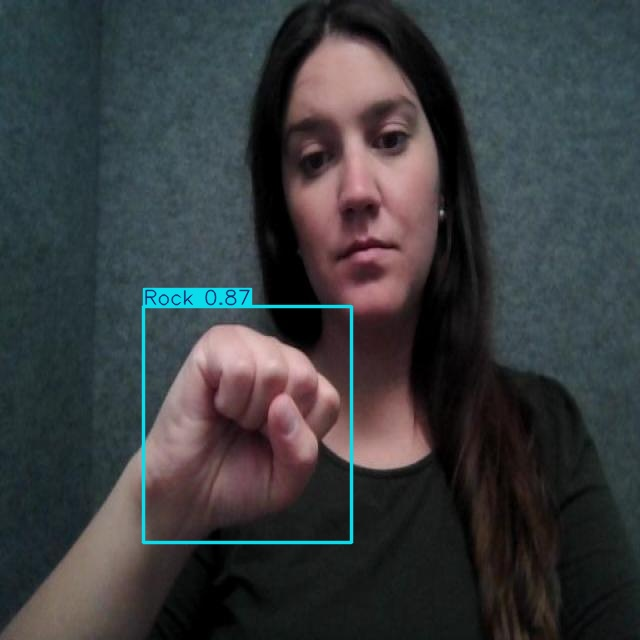

In [ ]:
show_image("/content/runs/detect/predict2/egohands-public-1622127403072_png_jpg.rf.19973115fbd57b8778d2dff1a80d5ced.jpg")

##  Export

Export a YOLO11 model to any supported format below with the `format` argument, i.e. `format=onnx`. See [YOLO11 Export Docs](https://docs.ultralytics.com/modes/export/) for more information.

- 💡 ProTip: Export to [ONNX](https://docs.ultralytics.com/integrations/onnx/) or [OpenVINO](https://docs.ultralytics.com/integrations/openvino/) for up to 3x CPU speedup.  
- 💡 ProTip: Export to [TensorRT](https://docs.ultralytics.com/integrations/tensorrt/) for up to 5x GPU speedup.

| Format                                                                   | `format` Argument | Model                     | Metadata | Arguments                                                            |
|--------------------------------------------------------------------------|-------------------|---------------------------|----------|----------------------------------------------------------------------|
| [PyTorch](https://pytorch.org/)                                          | -                 | `yolo11n.pt`              | ✅        | -                                                                    |
| [TorchScript](https://docs.ultralytics.com/integrations/torchscript)     | `torchscript`     | `yolo11n.torchscript`     | ✅        | `imgsz`, `optimize`, `batch`                                         |
| [ONNX](https://docs.ultralytics.com/integrations/onnx)                   | `onnx`            | `yolo11n.onnx`            | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `opset`, `batch`             |
| [OpenVINO](https://docs.ultralytics.com/integrations/openvino)           | `openvino`        | `yolo11n_openvino_model/` | ✅        | `imgsz`, `half`, `dynamic`, `int8`, `batch`, `data`                  |
| [TensorRT](https://docs.ultralytics.com/integrations/tensorrt)           | `engine`          | `yolo11n.engine`          | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `workspace`, `int8`, `batch`, `data` |
| [CoreML](https://docs.ultralytics.com/integrations/coreml)               | `coreml`          | `yolo11n.mlpackage`       | ✅        | `imgsz`, `half`, `int8`, `nms`, `batch`                              |
| [TF SavedModel](https://docs.ultralytics.com/integrations/tf-savedmodel) | `saved_model`     | `yolo11n_saved_model/`    | ✅        | `imgsz`, `keras`, `int8`, `batch`                                    |
| [TF GraphDef](https://docs.ultralytics.com/integrations/tf-graphdef)     | `pb`              | `yolo11n.pb`              | ❌        | `imgsz`, `batch`                                                     |
| [TF Lite](https://docs.ultralytics.com/integrations/tflite)              | `tflite`          | `yolo11n.tflite`          | ✅        | `imgsz`, `half`, `int8`, `batch`, `data`                             |
| [TF Edge TPU](https://docs.ultralytics.com/integrations/edge-tpu)        | `edgetpu`         | `yolo11n_edgetpu.tflite`  | ✅        | `imgsz`                                                              |
| [TF.js](https://docs.ultralytics.com/integrations/tfjs)                  | `tfjs`            | `yolo11n_web_model/`      | ✅        | `imgsz`, `half`, `int8`, `batch`                                     |
| [PaddlePaddle](https://docs.ultralytics.com/integrations/paddlepaddle)   | `paddle`          | `yolo11n_paddle_model/`   | ✅        | `imgsz`, `batch`                                                     |
| [MNN](https://docs.ultralytics.com/integrations/mnn)                     | `mnn`             | `yolo11n.mnn`             | ✅        | `imgsz`, `batch`, `int8`, `half`                                     |
| [NCNN](https://docs.ultralytics.com/integrations/ncnn)                   | `ncnn`            | `yolo11n_ncnn_model/`     | ✅        | `imgsz`, `half`, `batch`                                             |
| [IMX500](https://docs.ultralytics.com/integrations/sony-imx500)          | `imx`             | `yolov8n_imx_model/`      | ✅        | `imgsz`, `int8`, `data`                                              |
| [RKNN](https://docs.ultralytics.com/integrations/rockchip-rknn)          | `rknn`            | `yolo11n_rknn_model/`     | ✅        | `imgsz`, `batch`, `name`                                             |

In [ ]:
# Run inference on an image with YOLO11n
!yolo predict model=yolo11s.pt source="https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg"

100% 18.4M/18.4M [00:00<00:00, 499MB/s]
Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs

100% 1.34M/1.34M [00:00<00:00, 1.54MB/s]
image 1/1 /content/pexels-photo-13872248.jpeg: 448x640 6 persons, 50.7ms
Speed: 14.3ms preprocess, 50.7ms inference, 312.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


### Exporting in ONNX for faster Inferencing Speeds on CPU

In [ ]:
!yolo export model="/content/yolo11s.pt" format=onnx

Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel CPUs. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs

PyTorch: starting from '/content/yolo11s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (18.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<1.18.0', 'onnxslim>=0.1.56', 'onnxruntime'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 2.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.56...
ONNX: export success ✅ 5.3s, saved as '/content/yolo11s.onnx' (36.3 MB)

Export complete (6.3s)
Results saved to /content
Predict:         yolo predict task=detect model=/content/yolo11s.onnx imgsz=640  
Validate:   

### Exporting in TensorRT for faster Inferencing Speeds on GPU

In [ ]:
!yolo export model=yolo11n.pt format=engine

100% 5.35M/5.35M [00:00<00:00, 319MB/s]
WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.151 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.56...
ONNX: export success ✅ 6.0s, saved as 'yolo11n.onnx' (10.2 MB)
requirements: Ultralytics requirement ['tensorrt>7.0.0,!=10.1.0'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 67.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effe

## Python Usage

In [ ]:
from ultralytics import YOLO

# Load our trained model
model = YOLO('yolo11n.pt')  # load a pretrained model (recommended for training)

# Use the model
results = model.train(data='/content/drive/MyDrive/Yolo_Datasets/data.yaml', epochs=1)  # train the model
#results = model.val()  # evaluate model performance on the validation set
#results = model('/content/drive/MyDrive/Yolo_Datasets/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg')  # predict on an image
#results = model.export(format='onnx')  # export the model to ONNX format
#results = model.export(format='engine')

Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/drive/MyDrive/Yolo_Datasets/data.yaml, epochs=1, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_c

train: Scanning /content/drive/MyDrive/Yolo_Datasets/train/labels.cache... 6455 images, 2516 backgrounds, 0 corrupt: 100%|██████████| 6455/6455 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/drive/MyDrive/Yolo_Datasets/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100%|██████████| 576/576 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/train2
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1       2.2G      1.306      3.176      1.465          6        640: 100%|██████████| 404/404 [01:10<00:00,  5.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:04<00:00,  4.32it/s]


                   all        576        400      0.578      0.479      0.537      0.325

1 epochs completed in 0.023 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 5.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:03<00:00,  4.79it/s]


                   all        576        400       0.58      0.476      0.537      0.324
                 Paper        132        139      0.556      0.216       0.36       0.18
                  Rock        121        141       0.51       0.73      0.657      0.426
              Scissors        116        120      0.673      0.481      0.594      0.368
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train2


In [ ]:
from ultralytics import YOLO


model1 = YOLO("/content/runs/detect/train/weights/best.pt")
#source = ""
results = model1('/content/rock-paper-scissors-14/valid/images/egohands-public-1622127403072_png_jpg.rf.19973115fbd57b8778d2dff1a80d5ced.jpg')


image 1/1 /content/rock-paper-scissors-14/valid/images/egohands-public-1622127403072_png_jpg.rf.19973115fbd57b8778d2dff1a80d5ced.jpg: 640x640 1 Rock, 12.7ms
Speed: 2.7ms preprocess, 12.7ms inference, 145.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Paper', 1: 'Rock', 2: 'Scissors'}
 obb: None
 orig_img: array([[[80, 71, 51],
         [79, 70, 50],
         [77, 68, 48],
         ...,
         [76, 69, 54],
         [73, 66, 51],
         [72, 65, 50]],
 
        [[81, 72, 52],
         [80, 71, 51],
         [78, 69, 49],
         ...,
         [76, 69, 54],
         [73, 66, 51],
         [72, 65, 50]],
 
        [[83, 74, 54],
         [81, 72, 52],
         [79, 70, 50],
         ...,
         [75, 68, 53],
         [73, 66, 51],
         [72, 65, 50]],
 
        ...,
 
        [[74, 72, 78],
         [76, 74, 80],
         [76, 76, 82],
         ...,
         [23, 24, 14],
         [25, 27, 15],
         [26, 28, 16]],
 
        [[76, 76, 82],
         [75, 75, 81],
         [75, 74, 83],
         ...,
         [22, 24, 12],
         [24, 26, 14],
         [25, 27, 15]],
 
  